In [1]:
import numpy as np 
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.integrate import quad
import math as mt

In [2]:
epsilon0_SI = 8.854187817e-12 # F/m
c = 299792458 # m/s
radio_bohr = 5.29177210903e-11 # m
carga_electron = 1.602176634e-19 # C
masa_electron = 9.10938356e-31 # kg

In [3]:
# tiempo de vida del electron en el modelo de rutherford
t = (4 * np.pi**2 * epsilon0_SI**2 * radio_bohr**3 * masa_electron**2 * c**3) / (carga_electron**4)
print(f"El tiempo de vida del electrón en el modelo de Rutherford es: {t:.2e} segundos")


El tiempo de vida del electrón en el modelo de Rutherford es: 1.56e-11 segundos


## **Tema:** Estimadores

In [4]:
# Estimacion de la edad de los estudiantes de astronomia

# tomamos la muestra definida por las edades de los estudiantes presentes en el salon

M = np.array([24, 23, 26, 21, 21, 23, 22, 20, 25, 22, 20, 21, 150])

Definiendo el siguiente **estimador**($\hat{\mu}_y$):

$$
\hat{\mu}_y = \frac{\sum_i y_i}{N}
$$

Podemos calcular la edad promedio que será nuestra **estima Puntual**

In [5]:
# calculo de la edad promedio de la muestra

mu_M = np.mean(M)
print(f'La edad promedio de la muestra es: {mu_M:.4f} años')

La edad promedio de la muestra es: 32.1538 años


ejemplo pa prueba de hipotesis que depende de dos muestras.

In [6]:
x_med =  48.9
n_x = 125
S_x = 14.6

y_med =  43.5
n_y = 90 
S_y = 14.4

# significancia del test
alpha = 0.01

In [7]:
def normal(x, mu, sigma):
    return (1/(sigma * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - mu) / sigma) ** 2)

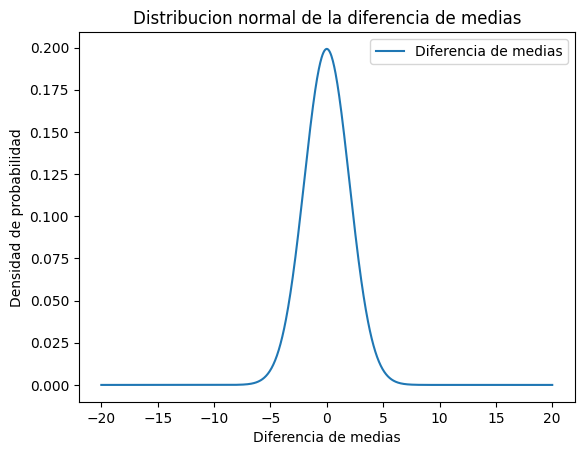

In [8]:
# parametros de la normal referidos a la diferencia de medias

mu_diff = 0 
sigma_diff = np.sqrt((S_x**2 / n_x) + (S_y**2 / n_y))

# calculo del valor critico para la cola derecha

normal_diff = lambda x: normal(x, mu_diff, sigma_diff)

# grafica de la distribucion normal de la diferencia de medias
x = np.linspace(-20, 20, 1000)
y = normal_diff(x)
plt.plot(x, y, label='Diferencia de medias')

plt.title('Distribucion normal de la diferencia de medias')
plt.xlabel('Diferencia de medias')
plt.ylabel('Densidad de probabilidad')
plt.legend()

In [9]:
condicion = 1 - alpha

# calculo del valor critico para la cola derecha
for i in range(len(x)):
    area, _ = quad(normal_diff, -np.inf, x[i])
    if abs(area - condicion) < 1e-3:
        z_critico = x[i]
        print(f'El valor critico para la cola derecha es: {z_critico:.4f}')
        break

# calculo del valor de la estadistica de prueba
x_medido = x_med - y_med

print(f'El valor de la estadistica de prueba es: {x_medido:.4f}')

El valor critico para la cola derecha es: 4.6246
El valor de la estadistica de prueba es: 5.4000


Según los datos dados, se puede concluir que se puede rechazar la hipotesis nula.

## **Métodos De Montecarlo**

Comparamos haciendo una prueba de hipotesis estandar usando un test de hipotesis de montecarlo a una de las estats I se tenian en el tiempo de vida de velas. Se tienen $n = 6$ observaciones:

`np.array([8.1, 8.7, 9.2, 7.8, 8.4, 9.4])`

con una varianza conocida $\sigma^2 = 0.4$. Las hipotesis nula $(H_0)$ y alterna $(H_a)$ son

$$
H_0 : \mu = 9.2  \quad \wedge \quad H_a: \mu \neq 9.2

$$

con $\text{P-value} = 2 P(Z > 2.32) = 0.0204$

In [10]:
# Datos observados
X_obs = np.array([8.1, 8.7, 9.2, 7.8, 8.4, 9.4])
n = len(X_obs)
sigma = 0.4**0.5
mu0 = 9.2


# Estadistico observado 
x_bar = np.mean(X_obs)
z_obs = (x_bar - mu0) / (sigma / np.sqrt(n))
print(f'Estadistico observado (z_obs): {z_obs:.4f}')

# simulacion monte carlo
num_simulaciones = 500000
z_sim = np.zeros(num_simulaciones)

for i in range(num_simulaciones):
    muestra = np.random.normal(loc=mu0, scale=sigma, size=n)
    z = (np.mean(muestra) - mu0) / (sigma / np.sqrt(n))
    z_sim[i] = z

# Estimar el p-valor como la proporción de simulaciones con |z_sim| >= |z_obs|

p_valor = np.mean(np.abs(z_sim) >= np.abs(z_obs))

print(f'Z observado: {z_obs:.4f}')
print(f'P-valor con montecarlo: {p_valor:.5f}')

Estadistico observado (z_obs): -2.3238
Z observado: -2.3238
P-valor con montecarlo: 0.02010


In [21]:
ns = np.linspace(1, 350, 350)
fdp = (365 - ns)/365

fdp_birthday = []

for i in range(len(ns)):
    fdp_birthday.append(np.prod(fdp[:i]))

fdp_birthday = np.array(fdp_birthday)


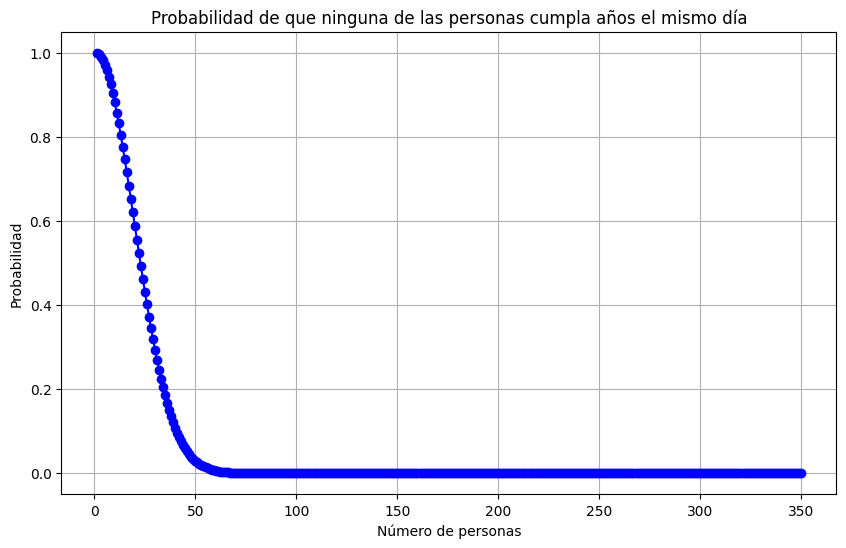

In [22]:
plt.figure(figsize=(10, 6))
plt.plot(ns, fdp_birthday, marker='o', linestyle='-', color='b')
plt.title('Probabilidad de que ninguna de las personas cumpla años el mismo día')
plt.xlabel('Número de personas')
plt.ylabel('Probabilidad')
plt.grid(True)
plt.show()

In [16]:
np.prod(fdp[:4])

np.float64(0.9728644263002065)